In [ ]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans,DBSCAN
from sklearn.preprocessing import StandardScaler

In [2]:
# Two interleaving crescents — NOT round blobs. K-Means will fail on this.
X, _ = make_moons(n_samples=300, noise=0.06, random_state=42)
X = StandardScaler().fit_transform(X)

# --- K-Means (must specify k=2) ---
km_labels = KMeans(n_clusters=2, n_init=10, random_state=42).fit_predict(X)

In [9]:
db = DBSCAN(eps=0.3,min_samples=5)
db_labels = db.fit_predict(X)
n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = list(db_labels).count(-1)
print("DBSCAN found", n_clusters, "clusters and", n_noise, "noise points (no k given)")

DBSCAN found 2 clusters and 0 noise points (no k given)


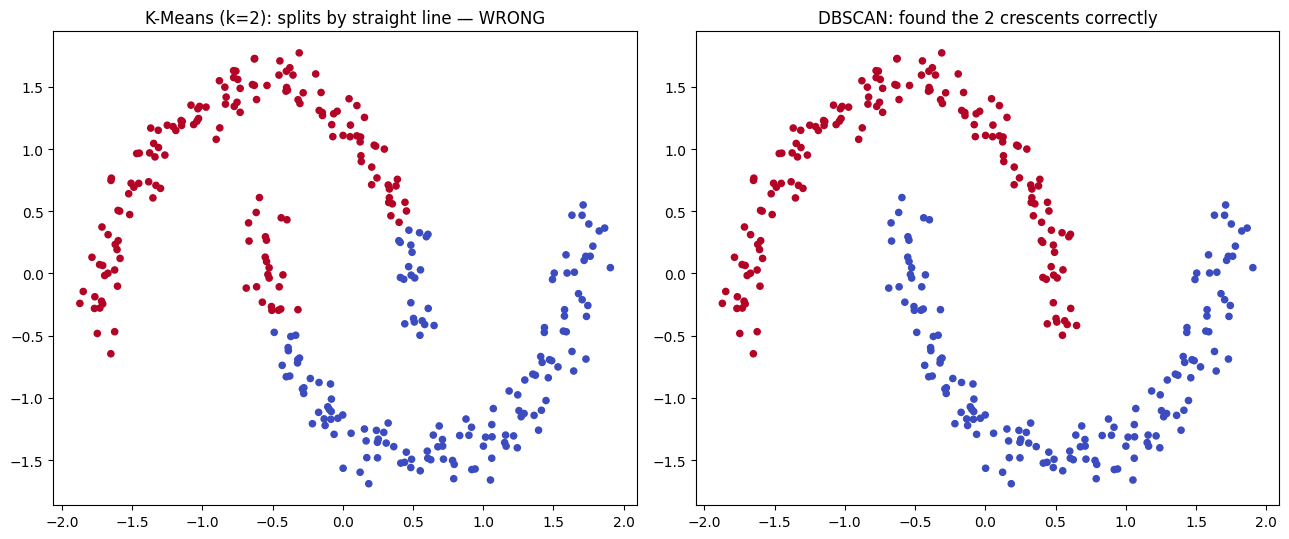

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))
ax[0].scatter(X[:,0], X[:,1], c=km_labels, cmap='coolwarm', s=20)
ax[0].set_title('K-Means (k=2): splits by straight line — WRONG')
ax[1].scatter(X[:,0], X[:,1], c=db_labels, cmap='coolwarm', s=20)
ax[1].set_title(f'DBSCAN: found the 2 crescents correctly')
plt.tight_layout(); plt.savefig('dbscan.png', dpi=110); plt.show()